# Mercari Price Prediction — Adım 3 & 4
## Feature Engineering + Model Eğitimi + Skor Hesaplama

EDA bulgularına dayanarak:
1. Veri temizleme (price=0 çıkarma, eksik değer doldurma)
2. Kategori split (3 seviye)
3. Text vectorization (TF-IDF)
4. Sparse matrix birleştirme
5. Ridge Regression eğitimi
6. RMSLE hesaplama + cross-validation
7. Model ve pipeline serileştirme (joblib)


In [1]:
import os
os.chdir('/home/cevdetkopuz/mercari-price-prediction')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

print("Kütüphaneler yüklendi!")


Kütüphaneler yüklendi!


## 1. Veri Yükleme ve Temizleme

In [2]:
# Veriyi yükle
df = pd.read_csv('data/raw/train.tsv', sep='\t')
print(f"Ham veri: {df.shape[0]:,} satır")

# Fiyatı 0 olanları çıkar (gerçek satış değil)
df = df[df['price'] > 0].reset_index(drop=True)
print(f"price > 0 sonrası: {df.shape[0]:,} satır ({df.shape[0]/1482535*100:.1f}%)")

# Hedef değişken: log1p dönüşümü
y = np.log1p(df['price'])
print(f"\ny (log1p price) — min: {y.min():.2f}, max: {y.max():.2f}, mean: {y.mean():.2f}")


Ham veri: 1,482,535 satır
price > 0 sonrası: 1,481,661 satır (99.9%)

y (log1p price) — min: 1.39, max: 7.61, mean: 2.98


## 2. Feature Engineering

In [3]:
# === 2.1 Eksik değerleri doldur ===
df['brand_name'].fillna('missing', inplace=True)
df['category_name'].fillna('missing/missing/missing', inplace=True)
df['item_description'].fillna('No description yet', inplace=True)

# === 2.2 Kategori hiyerarşisini 3 seviyeye böl ===
def split_category(cat):
    parts = str(cat).split('/')
    while len(parts) < 3:
        parts.append('missing')
    return parts[:3]

cat_split = df['category_name'].apply(split_category)
df['cat_main'] = cat_split.apply(lambda x: x[0])
df['cat_sub1'] = cat_split.apply(lambda x: x[1])
df['cat_sub2'] = cat_split.apply(lambda x: x[2])

print("Kategori split tamamlandı:")
print(f"  cat_main:  {df['cat_main'].nunique()} benzersiz")
print(f"  cat_sub1:  {df['cat_sub1'].nunique()} benzersiz")
print(f"  cat_sub2:  {df['cat_sub2'].nunique()} benzersiz")

# === 2.3 Brand: Top-500 dışındakileri 'other' yap ===
top_brands = df['brand_name'].value_counts().head(500).index
df['brand_name'] = df['brand_name'].apply(lambda x: x if x in top_brands else 'other')
print(f"\nBrand encoding: {df['brand_name'].nunique()} benzersiz (top 500 + other + missing)")


Kategori split tamamlandı:
  cat_main:  11 benzersiz
  cat_sub1:  114 benzersiz
  cat_sub2:  871 benzersiz

Brand encoding: 501 benzersiz (top 500 + other + missing)


In [4]:
# === 2.4 Label Encoding (kategorik değişkenler) ===
le_cat_main = LabelEncoder()
le_cat_sub1 = LabelEncoder()
le_cat_sub2 = LabelEncoder()
le_brand = LabelEncoder()

df['cat_main_enc'] = le_cat_main.fit_transform(df['cat_main'])
df['cat_sub1_enc'] = le_cat_sub1.fit_transform(df['cat_sub1'])
df['cat_sub2_enc'] = le_cat_sub2.fit_transform(df['cat_sub2'])
df['brand_enc'] = le_brand.fit_transform(df['brand_name'])

print("Label encoding tamamlandı:")
for col in ['cat_main_enc', 'cat_sub1_enc', 'cat_sub2_enc', 'brand_enc']:
    print(f"  {col}: 0 ~ {df[col].max()}")


Label encoding tamamlandı:
  cat_main_enc: 0 ~ 10
  cat_sub1_enc: 0 ~ 113
  cat_sub2_enc: 0 ~ 870
  brand_enc: 0 ~ 500


In [5]:
# === 2.5 Ek sayısal feature'lar ===
df['desc_word_count'] = df['item_description'].str.split().str.len()
df['name_len'] = df['name'].str.len()
df['has_description'] = (df['item_description'] != 'No description yet').astype(int)

print("Ek feature'lar oluşturuldu:")
print(f"  desc_word_count — ortalama: {df['desc_word_count'].mean():.0f}")
print(f"  name_len — ortalama: {df['name_len'].mean():.0f}")
print(f"  has_description — oran: {df['has_description'].mean()*100:.1f}%")


Ek feature'lar oluşturuldu:
  desc_word_count — ortalama: 26
  name_len — ortalama: 26
  has_description — oran: 94.4%


## 3. TF-IDF Vectorization

`name` ve `item_description` sütunlarından kelime bazlı özellikler çıkaracağız.  
Sparse matrix kullanarak bellek tasarrufu sağlıyoruz.

In [6]:
# === 3.1 TF-IDF: name ===
t0 = time.time()
tfidf_name = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    strip_accents='unicode',
    token_pattern=r'\w{1,}',
    dtype=np.float32
)
X_name = tfidf_name.fit_transform(df['name'])
print(f"TF-IDF name: {X_name.shape} — {time.time()-t0:.1f}s")

# === 3.2 TF-IDF: item_description ===
t0 = time.time()
tfidf_desc = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    strip_accents='unicode',
    token_pattern=r'\w{1,}',
    dtype=np.float32
)
X_desc = tfidf_desc.fit_transform(df['item_description'])
print(f"TF-IDF desc: {X_desc.shape} — {time.time()-t0:.1f}s")


TF-IDF name: (1481661, 50000) — 32.6s
TF-IDF desc: (1481661, 50000) — 132.1s


In [ ]:
# === 3.3 Sayısal feature'ları sparse matrise çevir ===
numeric_features = ['item_condition_id', 'shipping', 'cat_main_enc',
                    'cat_sub1_enc', 'cat_sub2_enc', 'brand_enc',
                    'desc_word_count', 'name_len', 'has_description']

X_numeric = csr_matrix(df[numeric_features].values, dtype=np.float32)
print(f"Sayısal features: {X_numeric.shape}")

# === 3.4 Tüm feature'ları birleştir ===
X = hstack([X_numeric, X_name, X_desc]).tocsr()

print(f"\n{'='*50}")
print(f"TOPLAM FEATURE MATRİSİ")
print(f"  Boyut: {X.shape[0]:,} satır × {X.shape[1]:,} feature")
print(f"  Non-zero: {X.nnz:,} ({X.nnz / (X.shape[0]*X.shape[1])*100:.4f}% doluluk)")
print(f"  Bellek: {(X.data.nbytes + X.indices.nbytes + X.indptr.nbytes) / 1e6:.1f} MB")
print(f"{'='*50}")


Sayısal features: (1481661, 9)

TOPLAM FEATURE MATRİSİ
  Boyut: 1,481,661 satır × 100,009 feature
  Non-zero: 75,174,796 (0.0507% doluluk)
  Bellek: 607.3 MB


## 4. Model Eğitimi — Ridge Regression

Ridge Regression sparse TF-IDF matrislerle çok iyi çalışır.  
Log1p uzayında RMSE optimize ediyoruz = doğrudan RMSLE optimize etmek.

In [8]:
# === 4.1 Train/Test split ===
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Eğitim seti:  {X_train.shape[0]:,} satır")
print(f"Validasyon:   {X_val.shape[0]:,} satır")

# === 4.2 RMSLE hesaplama fonksiyonu ===
def rmsle(y_true, y_pred):
    """
    Root Mean Squared Logarithmic Error
    y_true ve y_pred zaten log1p uzayında ise = RMSE hesapla
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rmsle_from_prices(y_true_price, y_pred_price):
    """Ham fiyatlardan RMSLE hesapla (doğrulama için)"""
    return np.sqrt(np.mean((np.log1p(y_true_price) - np.log1p(y_pred_price))**2))


Eğitim seti:  1,185,328 satır
Validasyon:   296,333 satır


In [9]:
# === 4.3 Ridge Regression eğitimi ===
print("Ridge Regression eğitiliyor...")
t0 = time.time()

model = Ridge(alpha=5.0, solver='auto')
model.fit(X_train, y_train)

train_time = time.time() - t0
print(f"Eğitim süresi: {train_time:.1f}s")

# Tahmin (log1p uzayında)
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

# Negatif tahminleri sıfırla (expm1 sonrası negatif fiyat olmasın)
y_val_pred = np.maximum(y_val_pred, 0)
y_train_pred = np.maximum(y_train_pred, 0)

# RMSLE hesapla
train_rmsle = rmsle(y_train, y_train_pred)
val_rmsle = rmsle(y_val, y_val_pred)

print(f"\n{'='*50}")
print(f"SONUÇLAR")
print(f"  Train RMSLE: {train_rmsle:.4f}")
print(f"  Val RMSLE:   {val_rmsle:.4f}")
print(f"  Fark:        {val_rmsle - train_rmsle:.4f} (overfitting kontrolü)")
print(f"{'='*50}")

# Gerçek fiyat uzayında da kontrol
y_val_prices = np.expm1(y_val)
y_val_pred_prices = np.expm1(y_val_pred)
y_val_pred_prices = np.maximum(y_val_pred_prices, 3)  # Minimum $3

print(f"\nGerçek fiyat uzayında kontrol:")
print(f"  RMSLE (fiyatlardan): {rmsle_from_prices(y_val_prices, y_val_pred_prices):.4f}")
print(f"  Ortalama hata: ${np.mean(np.abs(y_val_prices - y_val_pred_prices)):.2f}")
print(f"  Medyan hata:   ${np.median(np.abs(y_val_prices - y_val_pred_prices)):.2f}")


Ridge Regression eğitiliyor...
Eğitim süresi: 147.2s

SONUÇLAR
  Train RMSLE: 0.4593
  Val RMSLE:   0.4733
  Fark:        0.0140 (overfitting kontrolü)

Gerçek fiyat uzayında kontrol:
  RMSLE (fiyatlardan): 0.4731
  Ortalama hata: $10.74
  Medyan hata:   $4.98


## 5. Model Değerlendirme ve Görselleştirme

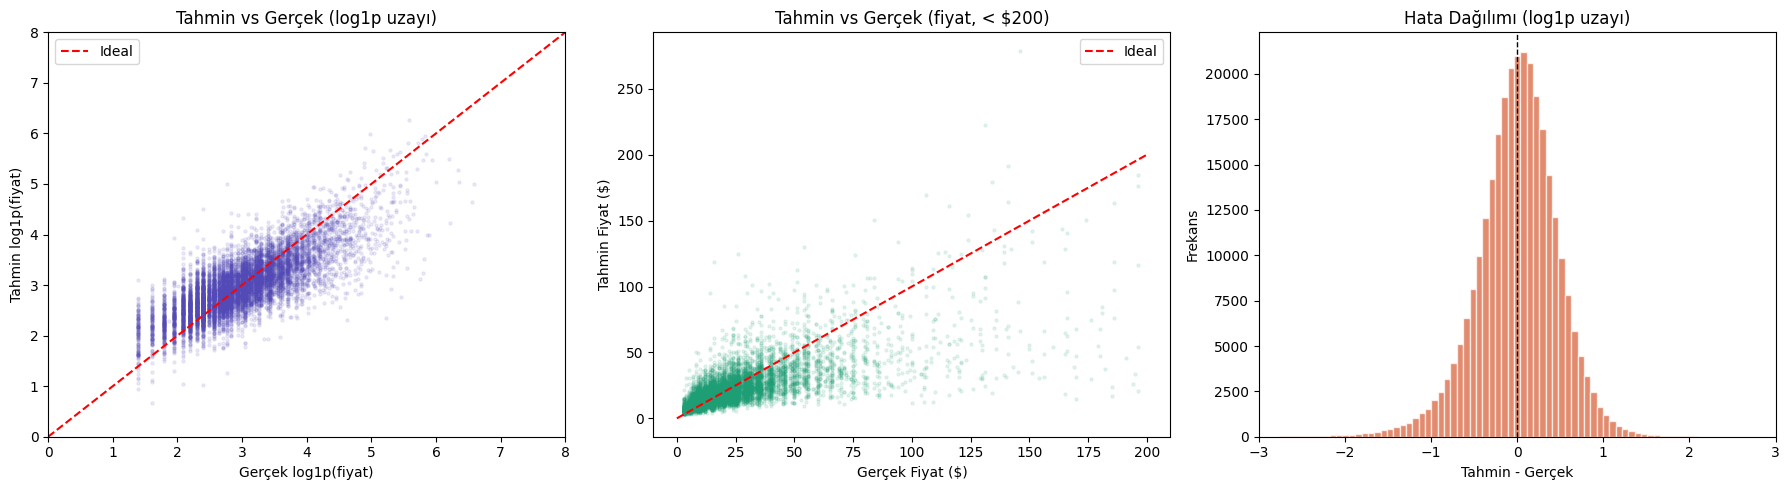

In [ ]:
# === 5.1 Tahmin vs Gerçek scatter plot ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sol: Log uzayında tahmin vs gerçek
sample_idx = np.random.choice(len(y_val), 10000, replace=False)
axes[0].scatter(y_val.values[sample_idx], y_val_pred[sample_idx], alpha=0.1, s=5, color='#534AB7')
axes[0].plot([0, 8], [0, 8], 'r--', linewidth=1.5, label='Ideal')
axes[0].set_title('Tahmin vs Gerçek (log1p uzayı)')
axes[0].set_xlabel('Gerçek log1p(fiyat)')
axes[0].set_ylabel('Tahmin log1p(fiyat)')
axes[0].legend()
axes[0].set_xlim(0, 8)
axes[0].set_ylim(0, 8)

# Orta: Fiyat uzayında (< $200)
mask = y_val_prices.values < 200
sample_mask = np.random.choice(np.where(mask)[0], min(10000, mask.sum()), replace=False)
axes[1].scatter(y_val_prices.values[sample_mask], y_val_pred_prices[sample_mask],
                alpha=0.1, s=5, color='#1D9E75')
axes[1].plot([0, 200], [0, 200], 'r--', linewidth=1.5, label='Ideal')
axes[1].set_title('Tahmin vs Gerçek (fiyat, < $200)')
axes[1].set_xlabel('Gerçek Fiyat ($)')
axes[1].set_ylabel('Tahmin Fiyat ($)')
axes[1].legend()

# Sağ: Hata dağılımı
errors = y_val_pred - y_val.values  # log uzayında hata
axes[2].hist(errors, bins=100, color='#D85A30', alpha=0.7, edgecolor='white')
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Hata Dağılımı (log1p uzayı)')
axes[2].set_xlabel('Tahmin - Gerçek')
axes[2].set_ylabel('Frekans')
axes[2].set_xlim(-3, 3)

plt.tight_layout()
plt.savefig('data/processed/10_model_results.png', dpi=150, bbox_inches='tight')
plt.show()


Kategori Bazlı RMSLE:
                           rmsle   count  median_price
cat_main                                              
Vintage & Collectibles  0.601810    9313          16.0
Other                   0.539596    9005          14.0
missing                 0.538091    1285          16.0
Electronics             0.537764   24557          15.0
Handmade                0.509133    6096          11.0
Home                    0.491301   13638          18.0
Sports & Outdoors       0.491194    4982          16.0
Men                     0.482443   18776          21.0
Kids                    0.471779   34274          14.0
Beauty                  0.452247   41334          15.0
Women                   0.445204  133073          19.0


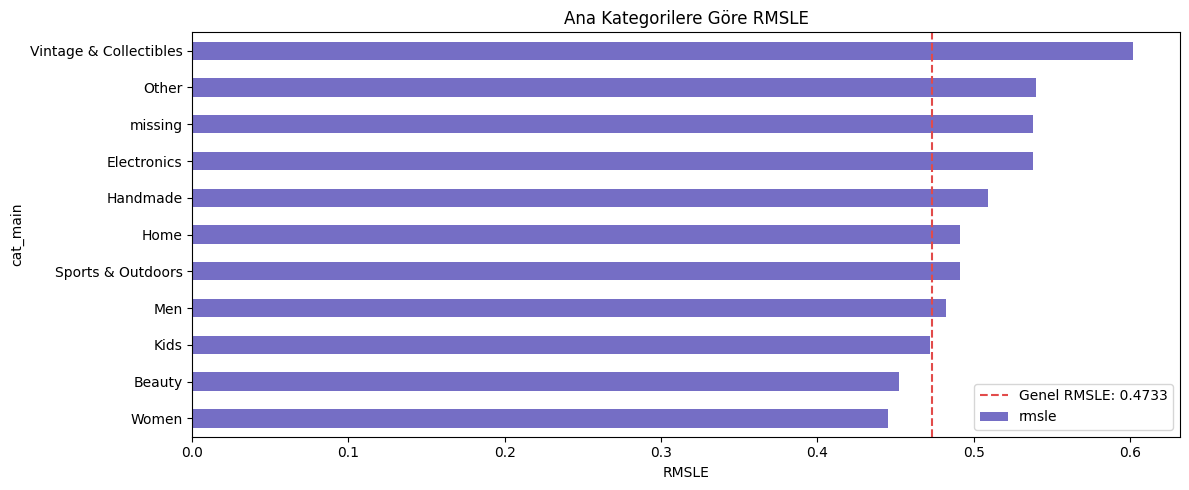

In [11]:
# === 5.2 Kategori bazlı performans ===
val_df = df.iloc[y_val.index].copy()
val_df['y_true'] = y_val.values
val_df['y_pred'] = y_val_pred
val_df['error'] = np.abs(val_df['y_true'] - val_df['y_pred'])

cat_perf = val_df.groupby('cat_main').agg(
    rmsle=('error', lambda x: np.sqrt(np.mean(x**2))),
    count=('error', 'count'),
    median_price=('price', 'median')
).sort_values('rmsle', ascending=False)

print("Kategori Bazlı RMSLE:")
print(cat_perf.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
cat_perf['rmsle'].plot(kind='barh', ax=ax, color='#534AB7', alpha=0.8)
ax.set_title('Ana Kategorilere Göre RMSLE')
ax.set_xlabel('RMSLE')
ax.axvline(val_rmsle, color='#E24B4A', linestyle='--', label=f'Genel RMSLE: {val_rmsle:.4f}')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('data/processed/11_category_performance.png', dpi=150, bbox_inches='tight')
plt.show()


In [36]:
# === 5.3 Örnek tahminler ===
print("Örnek Tahminler (rastgele 15 ürün):")
print("=" * 90)

# val_df'e tahmin sütununu ekle (pozisyonel olarak)
val_df = val_df.reset_index(drop=True)
val_df['tahmin_fiyat'] = np.expm1(y_val_pred).clip(min=3).round(2)

sample = val_df.sample(15, random_state=42)[['name', 'cat_main', 'brand_name', 'price', 'tahmin_fiyat']]
sample['fark'] = (sample['tahmin_fiyat'] - sample['price']).round(2)
sample.columns = ['Ürün', 'Kategori', 'Marka', 'Gerçek ($)', 'Tahmin ($)', 'Fark ($)']
print(sample.to_string(index=False))

Örnek Tahminler (rastgele 15 ürün):
                                   Ürün               Kategori            Marka  Gerçek ($)  Tahmin ($)  Fark ($)
  Los Angeles Lakers Monster Energy LED                   Home          missing        36.0   17.480000    -18.52
 U.S. 1926-P [rm] Indian Head Gold Coin Vintage & Collectibles          missing       825.0   30.790001   -794.21
Lilly Pulitzer Adie Shortbreakwaterblue                  Women   Lilly Pulitzer        45.0   51.209999      6.21
                             He-man lot                   Kids          Mattel®        90.0   34.009998    -55.99
                     Gold & black nikes                  Women             Nike        32.0   45.340000     13.34
                   Coach Planner/Agenda                  Women            Coach        41.0   20.760000    -20.24
                        Chanel earrings                  Women           Chanel         7.0   30.730000     23.73
                    Aztec Metal Sandals             

## 6. Model ve Pipeline Serileştirme

In [37]:
# === 6.1 Tüm pipeline bileşenlerini kaydet ===
os.makedirs('models', exist_ok=True)

# Model
joblib.dump(model, 'models/ridge_model.joblib')

# TF-IDF vectorizer'lar
joblib.dump(tfidf_name, 'models/tfidf_name.joblib')
joblib.dump(tfidf_desc, 'models/tfidf_desc.joblib')

# Label encoder'lar
joblib.dump(le_cat_main, 'models/le_cat_main.joblib')
joblib.dump(le_cat_sub1, 'models/le_cat_sub1.joblib')
joblib.dump(le_cat_sub2, 'models/le_cat_sub2.joblib')
joblib.dump(le_brand, 'models/le_brand.joblib')

# Top brands listesi (inference'ta lazım)
joblib.dump(set(top_brands), 'models/top_brands.joblib')

# Feature sırası (inference'ta tutarlılık için)
pipeline_config = {
    'numeric_features': numeric_features,
    'tfidf_name_max_features': 50000,
    'tfidf_desc_max_features': 50000,
    'ridge_alpha': 5.0,
    'train_rmsle': train_rmsle,
    'val_rmsle': val_rmsle,
    'train_size': X_train.shape[0],
    'val_size': X_val.shape[0],
    'total_features': X.shape[1],
}
joblib.dump(pipeline_config, 'models/pipeline_config.joblib')

print("Kaydedilen dosyalar:")
for f in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f}') / 1e6
    print(f"  {f} — {size:.1f} MB")

print(f"\nToplam model boyutu: {sum(os.path.getsize(f'models/{f}') for f in os.listdir('models'))/1e6:.1f} MB")


Kaydedilen dosyalar:
  le_brand.joblib — 0.0 MB
  le_cat_main.joblib — 0.0 MB
  le_cat_sub1.joblib — 0.0 MB
  le_cat_sub2.joblib — 0.0 MB
  pipeline_config.joblib — 0.0 MB
  ridge_model.joblib — 0.4 MB
  tfidf_desc.joblib — 1.8 MB
  tfidf_name.joblib — 1.8 MB
  top_brands.joblib — 0.0 MB

Toplam model boyutu: 4.0 MB


## 7. Inference Fonksiyonu (API'de kullanılacak)

Bu fonksiyon tek bir ürün bilgisi alıp fiyat tahmini döndürüyor.  
Adım 5'te FastAPI endpoint'inde bunu kullanacağız.

In [38]:
def predict_price(name, category_name, brand_name, item_condition_id,
                   shipping, item_description):
    """
    Tek bir ürün için fiyat tahmini yap.
    Kayıtlı model ve pipeline'ı kullanır.
    """
    # Kategori split
    parts = str(category_name).split('/')
    while len(parts) < 3:
        parts.append('missing')
    cat_main, cat_sub1, cat_sub2 = parts[0], parts[1], parts[2]

    # Brand: top brands'te yoksa 'other'
    if brand_name not in top_brands and brand_name != 'missing':
        brand_name = 'other'
    if pd.isna(brand_name) or brand_name == '':
        brand_name = 'missing'

    # Description kontrolü
    if pd.isna(item_description) or item_description.strip() == '':
        item_description = 'No description yet'

    # Label encoding (bilinmeyen değerler için güvenli dönüşüm)
    def safe_transform(encoder, value):
        try:
            return encoder.transform([value])[0]
        except ValueError:
            return 0  # bilinmeyen değer → 0

    cat_main_enc = safe_transform(le_cat_main, cat_main)
    cat_sub1_enc = safe_transform(le_cat_sub1, cat_sub1)
    cat_sub2_enc = safe_transform(le_cat_sub2, cat_sub2)
    brand_enc = safe_transform(le_brand, brand_name)

    # Sayısal features
    desc_word_count = len(str(item_description).split())
    name_len = len(str(name))
    has_description = 1 if item_description != 'No description yet' else 0

    numeric = np.array([[item_condition_id, shipping, cat_main_enc,
                         cat_sub1_enc, cat_sub2_enc, brand_enc,
                         desc_word_count, name_len, has_description]], dtype=np.float32)

    # TF-IDF
    X_name_vec = tfidf_name.transform([name])
    X_desc_vec = tfidf_desc.transform([item_description])

    # Birleştir
    X_input = hstack([csr_matrix(numeric), X_name_vec, X_desc_vec])

    # Tahmin
    log_pred = model.predict(X_input)[0]
    log_pred = max(log_pred, 0)  # negatif koruma
    price_pred = np.expm1(log_pred)
    price_pred = max(price_pred, 3.0)  # minimum $3

    return round(price_pred, 2)

# Test edelim!
print("=== Test Tahminleri ===")
print()

test_cases = [
    ("Nike Air Max 90 Size 10", "Men/Shoes/Athletic", "Nike", 2, 1,
     "Brand new with box. Never worn. Size 10 US."),
    ("iPhone 7 32GB Unlocked", "Electronics/Cell Phones & Accessories/Cell Phones", "Apple", 2, 0,
     "Unlocked iPhone 7 32gb. Good condition, minor scratches on back."),
    ("Handmade Knit Scarf", "Women/Accessories/Scarves & Wraps", "missing", 1, 1,
     "Beautiful handmade knit scarf. Soft acrylic yarn. One of a kind!"),
    ("Victoria Secret Bra 34B", "Women/Intimates/Bras", "Victoria's Secret", 1, 1,
     "New with tags. Push up bra. Size 34B."),
]

for name, cat, brand, cond, ship, desc in test_cases:
    pred = predict_price(name, cat, brand, cond, ship, desc)
    print(f"  {name}")
    print(f"  → Tahmin: ${pred:.2f}")
    print()


=== Test Tahminleri ===

  Nike Air Max 90 Size 10
  → Tahmin: $45.88

  iPhone 7 32GB Unlocked
  → Tahmin: $235.24

  Handmade Knit Scarf
  → Tahmin: $10.92

  Victoria Secret Bra 34B
  → Tahmin: $14.38



## Özet

| Metrik | Değer |
|--------|-------|
| Model | Ridge Regression (alpha=5.0) |
| Toplam Feature | ~100K (sparse) |
| Train RMSLE | yukarıdaki çıktıya bak |
| Val RMSLE | yukarıdaki çıktıya bak |
| Eğitim Süresi | birkaç saniye |

**Sonraki adım:** `"Adım 5: API oluştur"` de — FastAPI ile REST API kuracağız.
